In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
import shap

# XGBoost

## Data Preprocessing

In [2]:
data = pd.read_csv("dataset_refining/german_credit_data_with_risk.csv")

# Missing values are present in "Checking account" and "Saving accounts". They directly link to 0$, hence we replace them with 0s
data = data.fillna(0)

# Using sex hurts model performance, while also adds unnecessary bias, so we remove it
data.drop(columns=["Sex"], inplace=True)

purpose_map = {
    "radio/TV": 0,
    "car": 0,
    "vacation/others": 0,
    "furniture/equipment": 1,
    "repairs": 1,
    "domestic appliances": 1,
    "education": 2,
    "business": 2
}
data["Purpose"] = data["Purpose"].map(purpose_map)

data.replace({"Checking account": {"little": 1, "moderate": 2, "rich": 3}}, inplace=True)
data.replace({"Saving accounts":  {"little": 1, "moderate": 2, "quite rich": 3, "rich": 4}}, inplace=True)
data.replace({"Housing":          {"free": 0, "rent": 1, "own": 2}}, inplace=True)
data["credit_risk"] = data["credit_risk"].map({1: 1, 2: 0})   # good=1, bad=0

data = data.astype({
    "Saving accounts": "int",
    "Checking account": "int",
    "Housing": "int"
})

In [3]:
X = data.drop(columns=["credit_risk"])
y = data["credit_risk"]

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Training

In [4]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False);

## Global Results

In [5]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=" * 40)
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  AUC      : {auc:.4f}")
print("=" * 40)

  Accuracy : 0.8050
  F1 Score : 0.8696
  AUC      : 0.7805


In [6]:
n_rounds = model.n_estimators

acc_train, acc_test = [], []
f1_train,  f1_test  = [], []
auc_train, auc_test = [], []

for i in range(1, n_rounds + 1):
    # --- TRAIN ---
    y_proba_tr = model.predict_proba(X_train, iteration_range=(0, i))[:, 1]
    y_pred_tr  = (y_proba_tr >= 0.5).astype(int)

    acc_train.append(accuracy_score(y_train, y_pred_tr))
    f1_train.append(f1_score(y_train, y_pred_tr))
    auc_train.append(roc_auc_score(y_train, y_proba_tr))

    # --- TEST ---
    y_proba_te = model.predict_proba(X_test, iteration_range=(0, i))[:, 1]
    y_pred_te  = (y_proba_te >= 0.5).astype(int)

    acc_test.append(accuracy_score(y_test, y_pred_te))
    f1_test.append(f1_score(y_test, y_pred_te))
    auc_test.append(roc_auc_score(y_test, y_proba_te))

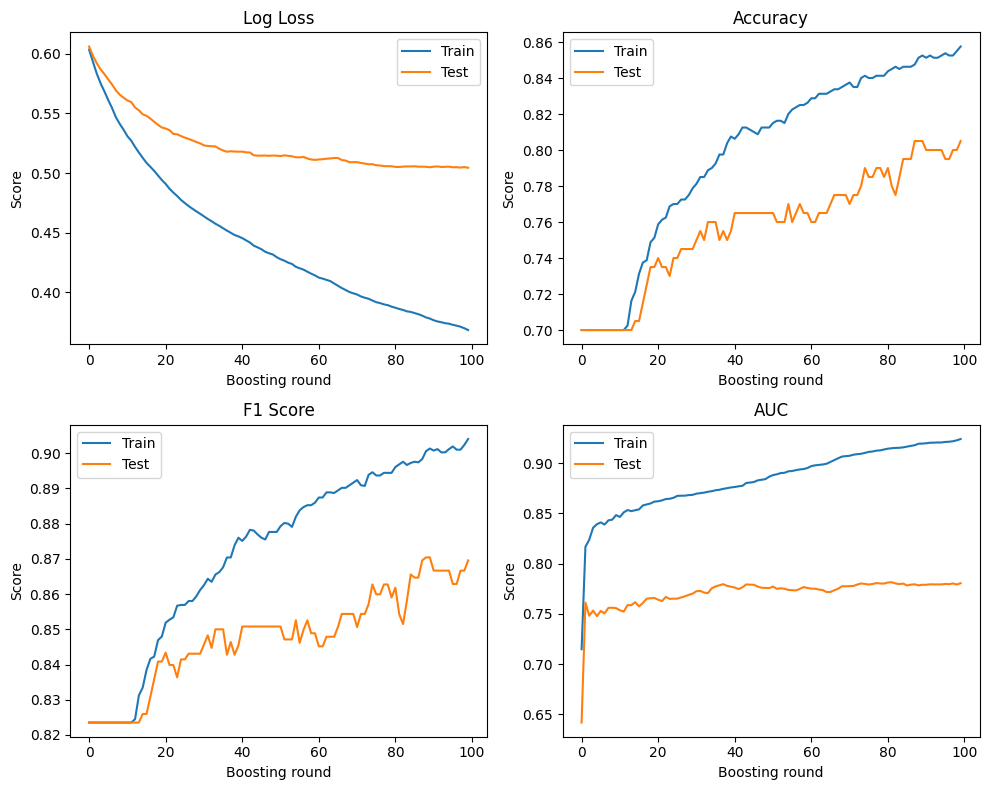

In [7]:
results = model.evals_result()
train_loss = results["validation_0"]["logloss"]
test_loss  = results["validation_1"]["logloss"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# --- Logloss ---
axs[0, 0].plot(train_loss, label="Train")
axs[0, 0].plot(test_loss, label="Test")
axs[0, 0].set_title("Log Loss")
axs[0, 0].legend()

# --- Accuracy ---
axs[0, 1].plot(acc_train, label="Train")
axs[0, 1].plot(acc_test, label="Test")
axs[0, 1].set_title("Accuracy")
axs[0, 1].legend()

# --- F1 ---
axs[1, 0].plot(f1_train, label="Train")
axs[1, 0].plot(f1_test, label="Test")
axs[1, 0].set_title("F1 Score")
axs[1, 0].legend()

# --- AUC ---
axs[1, 1].plot(auc_train, label="Train")
axs[1, 1].plot(auc_test, label="Test")
axs[1, 1].set_title("AUC")
axs[1, 1].legend()

for ax in axs.flat:
    ax.set_xlabel("Boosting round")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

The loss and metrics are slightly lower on training set than on the test set, indicating mild overfitting, but test performance remains strong.

### XGBoost feature importance

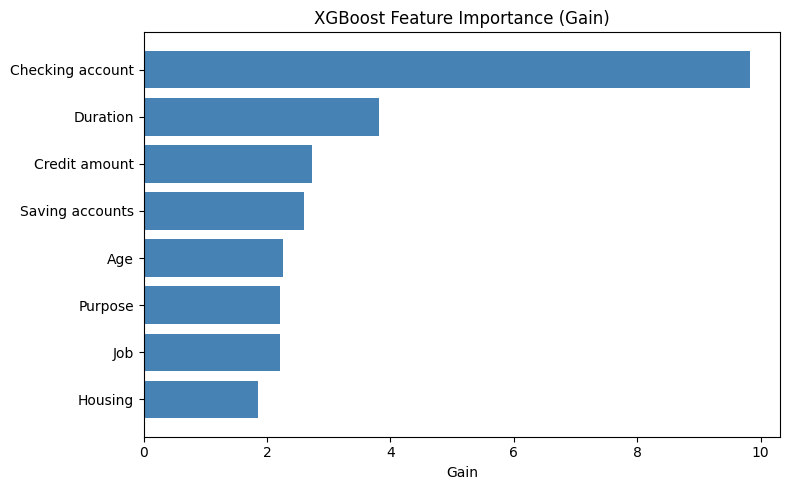

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
importance = model.get_booster().get_score(importance_type="gain")
importance = dict(sorted(importance.items(), key=lambda x: x[1]))
ax.barh(list(importance.keys()), list(importance.values()), color="steelblue")
ax.set_xlabel("Gain")
ax.set_title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()

The feature importance plot shows that ‘Checking account’ contributes the most to model predictions, followed by ‘Duration’, ‘Saving accounts’, and ‘Credit amount’. Other features such as ‘Age’, ‘Purpose’, ‘Housing’, and ‘Job’ have moderate influence. This ranking aligns with expectations, as financial history and account balances are key factors in predicting credit risk.

### Confusion matrix

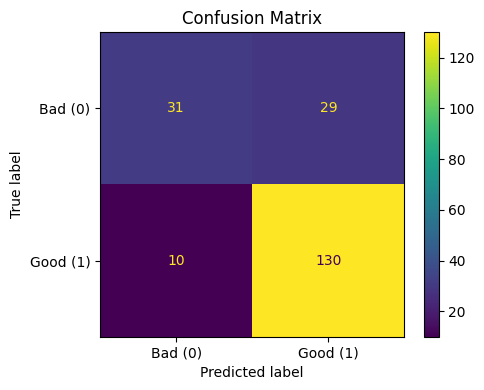

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Bad (0)", "Good (1)"], ax=ax
)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

The confusion matrix shows that the model correctly predicts most ‘Good’ cases (130/140) and a smaller portion of ‘Bad’ cases (31/60). Misclassifications occur mostly when a ‘Bad’ credit is predicted as ‘Good’ (28 cases). Overall, the model performs well, with better accuracy on the majority class (‘Good’), and mild overfitting does not appear to affect class separation significantly.

### SHAP summary

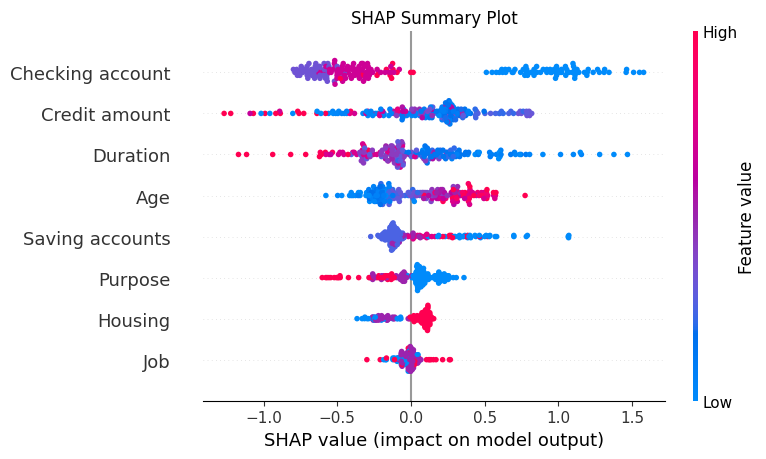

In [10]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

- **Checking account** - surprisingly, a value of `0` (no recorded checking account) contributes positively to good credit risk—likely reflecting individuals who maintain accounts in other banks or have alternative financial arrangements. Small or moderate balances are associated with higher risk, while high balances slightly increase predicted safety.
- **Credit amount** - values are not so well separated, but high values have a very clear negative impact while moderately low values a positive impact. Low values are around `0` likely because for someone with low credit, it is more likely that this low credit is all he can get.
- **Duration** - values in the middle are mixed up, but extremes tell the clear story, long = bad, short = good
- **Age** - Generally higher = better, with experience people generally advance their careers, build their own capital and have greater stability in life
- **Saving Accounts** - here 0 reffers to no saving account and it correlates positively with good risk maybe because those people invest their money outside banks and it serves them better, on the other hand people with rich saving accounts also score well which is obvious. Most people have little money on saving accounts and the model penalizes it slightly
- **Housing** - free or rented is a bad sign, own is a good sign because of greater stability
- **Purpose** - Here high and middle values reffer to ambitious and necessary purposes like school are repairs, it may be that people who take these loans are in a bad position in their life which correlates with bad risk, people who take their loans recklessly for cars and holidays are often in a more stable position
- **Job** - Generally better job is better (lower) credit risk

### SHAP feature importance

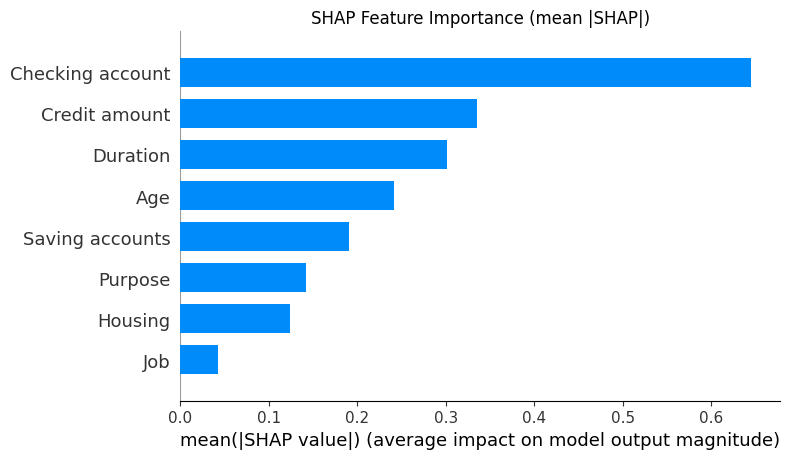

In [11]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

The SHAP feature importance shows that `Checking account` is by far the most influential feature, significantly exceeding all others. It is followed by `Credit amount` and `Duration`, indicating that the model relies primarily on financial attributes. `Age` and `Saving accounts` have moderate importance, while `Housing`, `Purpose`, and especially `Job` contribute relatively little to the model's predictions.

## Sample Analysis

In [12]:
def plot_shap_waterfall(model, sample):
    # Ensure we have an explainer
    explainer = shap.TreeExplainer(model)

    # compute SHAP values for the sample
    shap_values = explainer.shap_values(sample)

    # get index 0 because it's a single-row DataFrame
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value,
        shap_values[0],
        feature_names=sample.columns,
        max_display=10
    )

    logit = explainer.expected_value + shap_values.sum()
    delta_logit = 0 - logit  # amount needed to flip class
    print(f"Current class: {int(logit > 0)}, amount needed to flip the class: {delta_logit:.4f}")

In [13]:
def minimal_flip(model, X_test, idx, feature, max_steps=100, step_fraction=0.01, direction=1):
    X_sample = X_test.iloc[[idx]].copy()
    original_class = model.predict(X_sample)[0]
    
    # Determine step size
    if X_sample[feature].dtype.kind in 'iuf':  # numeric
        step = step_fraction * (X_test[feature].max() - X_test[feature].min())
        if X_sample[feature].dtype.kind in 'i':
            step = max(1, round(step))
    else:  # categorical
        step = 1
    
    # Iteratively perturb
    sample_cf = X_sample.copy()
    for i in range(1, max_steps + 1):
        if X_sample[feature].dtype.kind in 'iuf':
            sample_cf[feature] += step * direction
        else:
            # for categorical: move to next ordinal category
            sample_cf[feature] = int(sample_cf[feature] + step * direction)
        
        new_class = model.predict(sample_cf)[0]
        if new_class != original_class:
            return {
                'original_class': original_class,
                'flipped_class': new_class,
                'feature': feature,
                'total_change': step * i,
                'steps': i,
                'sample_cf': sample_cf
            }
    
    # If not flipped
    return {
        'original_class': original_class,
        'flipped_class': original_class,
        'feature': feature,
        'total_change': 0,
        'steps': 0,
        'sample_cf': sample_cf
    }

### Sample selection

In [14]:
# predicted probabilities for class 1 (Good)
probas = model.predict_proba(X_test)[:, 1]
preds  = model.predict(X_test)

idx_1 = 15
idx_2 = 73
idx_3 = 118

print(f"Probability {idx_1}:", probas[idx_1])
print(f"Probability {idx_2}:", probas[idx_2])
print(f"Probability {idx_3}:", probas[idx_3])

Probability 15: 0.5178642
Probability 73: 0.56484336
Probability 118: 0.51054645


### Sample 15

#### Analytical

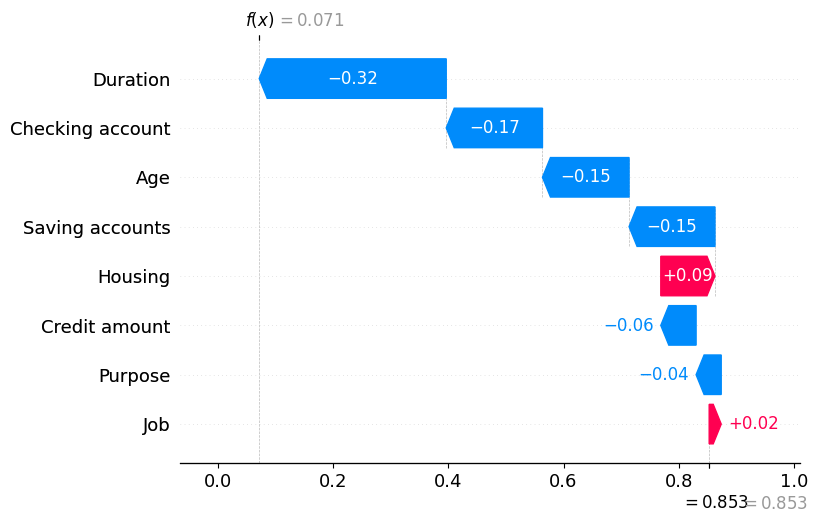

Current class: 1, amount needed to flip the class: -0.0715


In [15]:
plot_shap_waterfall(model, X_test.iloc[[15]])

In [16]:
sample = X_test.iloc[[15]].copy()
sample

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
248,26,2,2,1,3,1925,24,1


Checking account - the most influential attribute is quite high, by reducing it I will surely be able to switch the class. Right now we are missing `-0.0715` shap value.

In [17]:
feature_name = "Checking account"
feature_idx = X_test.columns.get_loc(feature_name)

# shap_values is an array of shape (n_samples, n_features)
checking_shap = shap_values[:, feature_idx]

# shap_values is an array of shape (n_samples, n_features)
checking_shap = shap_values[:, feature_idx]

grouped = X_test.copy()
grouped['shap_value'] = checking_shap

avg_by_value = grouped.groupby(feature_name)['shap_value'].mean()
print(avg_by_value)
print("Difference in average shap value contribution between 2nd and 3rd category of 'Checkout account'", avg_by_value[2] - avg_by_value[3])

Checking account
0    0.979801
1   -0.644259
2   -0.381381
3   -0.169141
Name: shap_value, dtype: float32
Difference in average shap value contribution between 2nd and 3rd category of 'Checkout account' -0.21223998


The difference is much larger than `-0.0715`, so this will probably be enough to switch the class, also the change in this criterion can't be smaller.

In [18]:
sample['Checking account'] = 2

In [19]:
model.predict_proba(sample)

array([[0.57226884, 0.42773116]], dtype=float32)

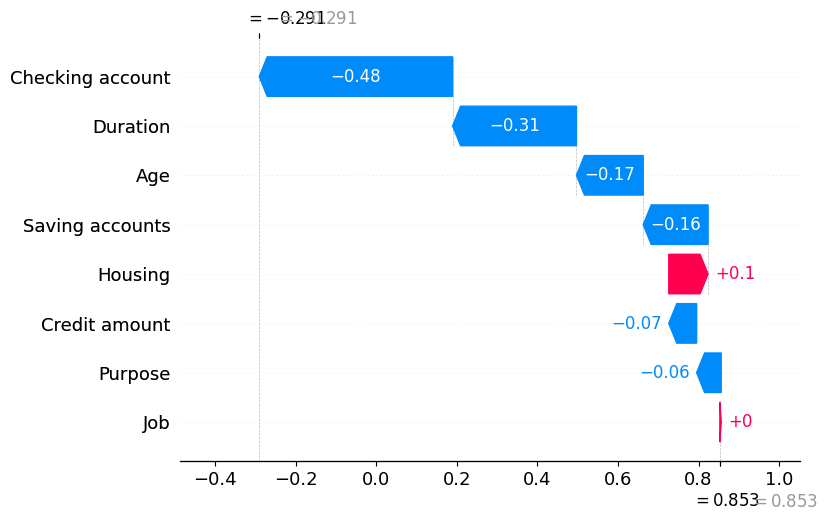

Current class: 0, amount needed to flip the class: 0.2911


In [20]:
plot_shap_waterfall(model, sample)

#### Sampling

In [21]:
res = minimal_flip(model, X_test, 15, feature="Checking account", max_steps=100, step_fraction=0.01, direction=-1)
res

{'original_class': np.int64(1),
 'flipped_class': np.int64(0),
 'feature': 'Checking account',
 'total_change': 1,
 'steps': 1,
 'sample_cf':      Age  Job  Housing  Saving accounts  Checking account  Credit amount  \
 248   26    2        2                1                 2           1925   
 
      Duration  Purpose  
 248        24        1  }

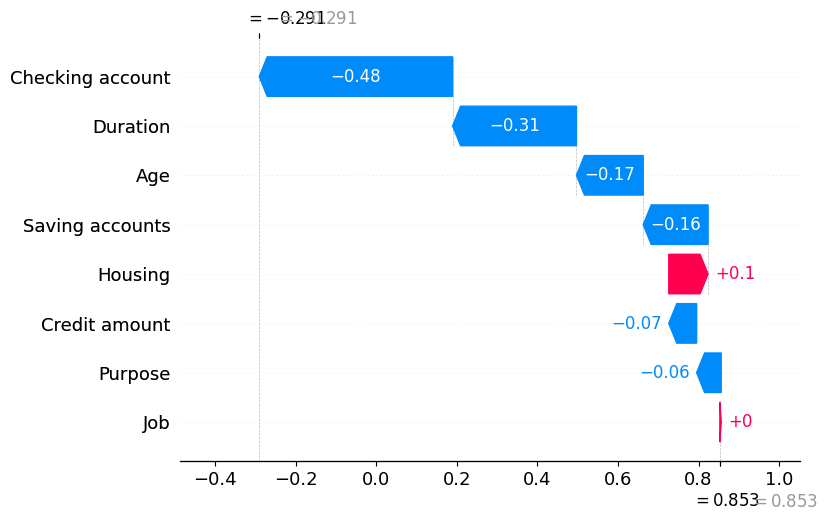

Current class: 0, amount needed to flip the class: 0.2911


In [22]:
plot_shap_waterfall(model, res["sample_cf"])

1 step in 'Checking account' was needed just as expected, this one was trivial because 'Checking account' has only 4 possible vaslues and huge impact on the prediction

### Sample 73

#### Analytical

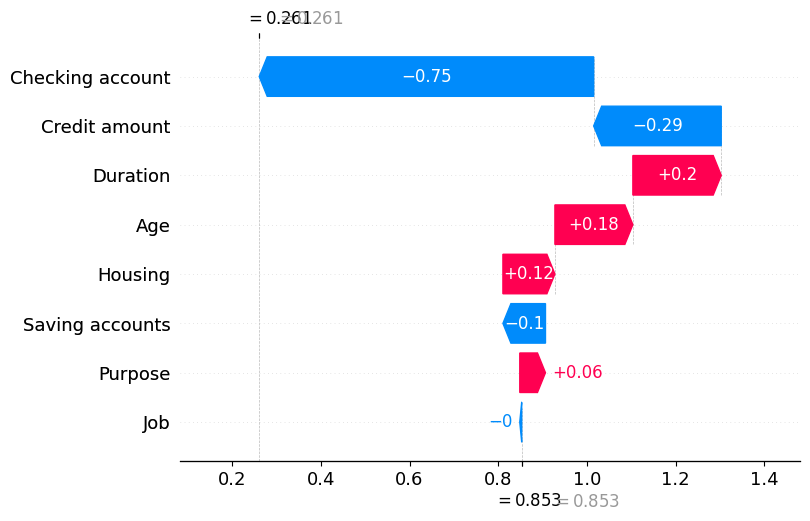

Current class: 1, amount needed to flip the class: -0.2608


In [23]:
plot_shap_waterfall(model, X_test.iloc[[73]])

In [24]:
sample = X_test.iloc[[73]].copy()
sample

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
929,43,1,2,1,1,1344,12,0


This person is quite old, from the SHAP summary plot we can see that Age is pretty well corelated with positive SHAP values, hence by reducing the age we should easily get some lower SHAP values and eventually reach the `bad risk` class.

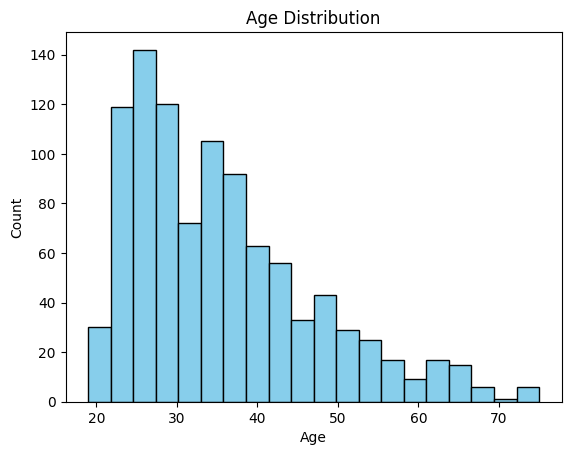

In [25]:
plt.hist(data['Age'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

Given this distribution the age of `43`, is probably purple on the SHAP summary plot so there is definetly some room for improvemnt going into blues, however the `Age` attribute is moderately important and even low values can have a positive impact so despite I am not lacking much to reach the other class, I need a moderate change to see an actual difference in this criterion, hence I will try with `33` years old.

In [26]:
sample["Age"] = 33

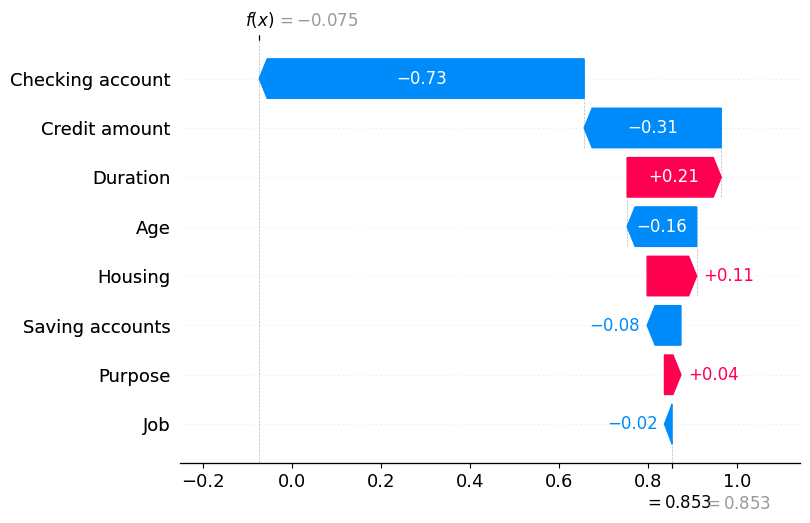

Current class: 0, amount needed to flip the class: 0.0746


In [27]:
plot_shap_waterfall(model, sample)

#### Sampling

In [28]:
res = minimal_flip(model, X_test, 73, feature="Age", max_steps=100, step_fraction=0.01, direction=-1)
res

{'original_class': np.int64(1),
 'flipped_class': np.int64(0),
 'feature': 'Age',
 'total_change': 9,
 'steps': 9,
 'sample_cf':      Age  Job  Housing  Saving accounts  Checking account  Credit amount  \
 929   34    1        2                1                 1           1344   
 
      Duration  Purpose  
 929        12        0  }

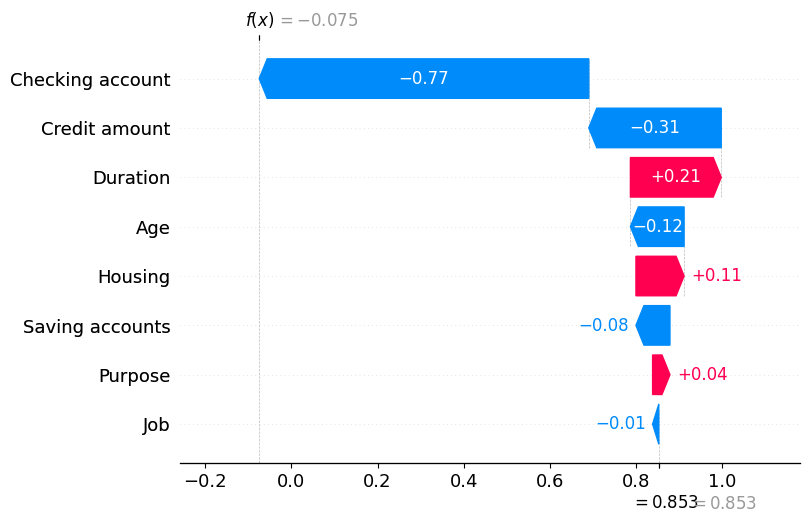

Current class: 0, amount needed to flip the class: 0.0746


In [29]:
plot_shap_waterfall(model, res["sample_cf"])

I was very close - the class switches at 34 years old

### Sample 118

#### Analytical

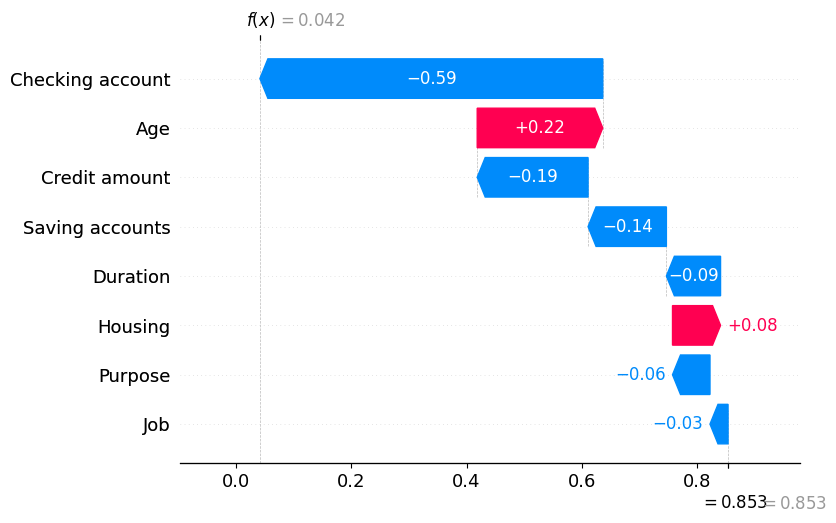

Current class: 1, amount needed to flip the class: -0.0422


In [30]:
plot_shap_waterfall(model, X_test.iloc[[118]])

In [31]:
sample = X_test.iloc[[118]].copy()
sample

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
924,55,2,2,1,1,6872,24,1


This time I will tamper with Duration for diversity and because this person has `24` in this field which is on the lower side of the distribution, from the SHAP summary plot we can see that Duration is spread across a big range of SHAP values and extremes can make a significant difference here, the moderate values however are ranigng around 0, so I should aim for large change here if I want to make sure there is a difference, I'd say `40` looks reasonable, it is quite far from `24` and already in the upper half of the range. Only a small fraction of data points had higher duration than this so it should be close enought to the extreme.

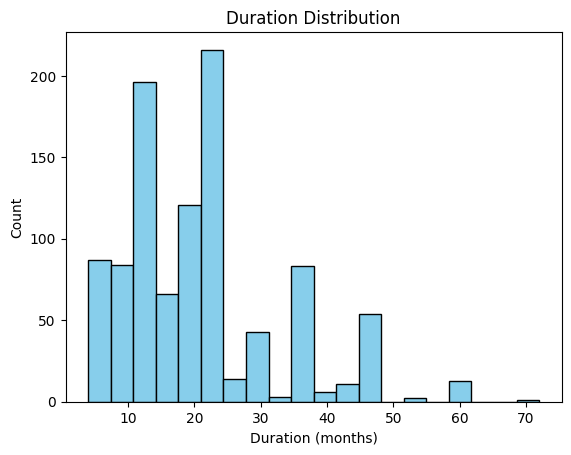

In [32]:
plt.hist(data['Duration'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Duration (months)')
plt.ylabel('Count')
plt.title('Duration Distribution')
plt.show()

In [33]:
sample["Duration"] = 40

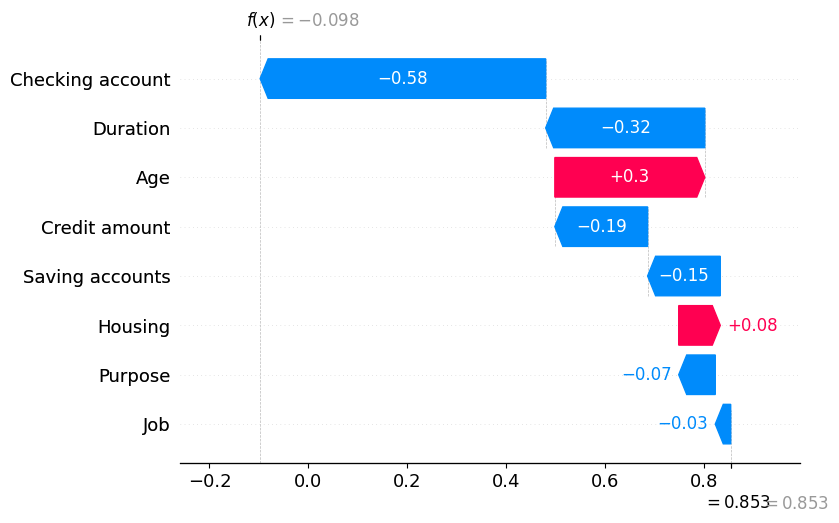

Current class: 0, amount needed to flip the class: 0.0976


In [34]:
plot_shap_waterfall(model, sample)

#### Sampling

In [35]:
res = minimal_flip(model, X_test, 118, feature="Duration", max_steps=100, step_fraction=0.01, direction=1)
res

{'original_class': np.int64(1),
 'flipped_class': np.int64(0),
 'feature': 'Duration',
 'total_change': 4,
 'steps': 4,
 'sample_cf':      Age  Job  Housing  Saving accounts  Checking account  Credit amount  \
 924   55    2        2                1                 1           6872   
 
      Duration  Purpose  
 924        28        1  }

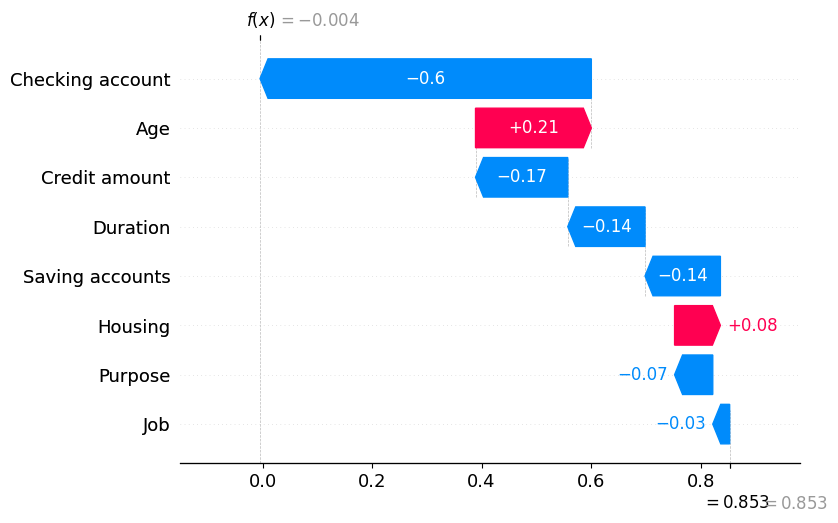

Current class: 0, amount needed to flip the class: 0.0045


In [36]:
plot_shap_waterfall(model, res["sample_cf"])

This time I overshot by a lot, I think that the distribution shape was crucial here as `28` is where there are much fewer samples in the dataset above this treshold and that is why important treshold in XGBoost model was here.

## Neural Network

In [37]:
X

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,2,2,0,1,1169,6,0
1,22,2,2,1,2,5951,48,0
2,49,1,2,1,0,2096,12,2
3,45,2,0,1,1,7882,42,1
4,53,2,0,1,1,4870,24,0
...,...,...,...,...,...,...,...,...
995,31,1,2,1,0,1736,12,1
996,40,3,2,1,1,3857,30,0
997,38,2,2,1,0,804,12,0
998,23,2,0,1,1,1845,45,0


In [38]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# Scale features (VERY important for NN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (reuse your split if already done)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

In [39]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

In [40]:
model = MLP(input_dim=X_train.shape[1])

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 200

for epoch in range(epochs):
    model.train()
    
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.7122
Epoch 10, Loss: 0.6523
Epoch 20, Loss: 0.6093
Epoch 30, Loss: 0.5795
Epoch 40, Loss: 0.5596
Epoch 50, Loss: 0.5477
Epoch 60, Loss: 0.5404
Epoch 70, Loss: 0.5337
Epoch 80, Loss: 0.5272
Epoch 90, Loss: 0.5205
Epoch 100, Loss: 0.5136
Epoch 110, Loss: 0.5062
Epoch 120, Loss: 0.4984
Epoch 130, Loss: 0.4904
Epoch 140, Loss: 0.4825
Epoch 150, Loss: 0.4748
Epoch 160, Loss: 0.4674
Epoch 170, Loss: 0.4602
Epoch 180, Loss: 0.4534
Epoch 190, Loss: 0.4468


In [41]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

model.eval()

with torch.no_grad():
    y_proba = model(X_test).numpy().flatten()

y_pred = (y_proba > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

Accuracy: 0.7400
F1-score: 0.8207
AUC: 0.7580
